<a href="https://colab.research.google.com/github/ftayebi/CloudSegmentation/blob/main/CloudSegmentationProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔵 **Data Loading & Preprocessing**

# Check GPU / CUDA Availability

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU is NOT available")

CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


# Install and Import Required Libraries

In [ ]:
!pip install -q segmentation-models-pytorch

In [ ]:
import os
import zipfile

from PIL import Image

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
%matplotlib inline

import albumentations as albu
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn as nn

import cv2

import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

import segmentation_models_pytorch as smp

# Load DATA

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


# =========================
# Paths
# =========================

DATA_DIR = "/content/drive/MyDrive"

CLOUD_DATA_ZIP = os.path.join(DATA_DIR, "cloud-data.zip")
TEST_ZIP = os.path.join(DATA_DIR, "test_images.zip")


# =========================
# Extract training data
# =========================

TRAIN_DATA_DIR = "/content/cloud_data"

with zipfile.ZipFile(CLOUD_DATA_ZIP, "r") as zip_ref:
    zip_ref.extractall(TRAIN_DATA_DIR)


# =========================
# Extract test data
# =========================

TEST_DATA_DIR = "/content/test_images"

with zipfile.ZipFile(TEST_ZIP, "r") as zip_ref:
    zip_ref.extractall(TEST_DATA_DIR)


# =========================
# Actual data paths
# =========================

TRAIN_IMAGES_DIR = "/content/cloud_data/data/train_images"
TRAIN_CSV = "/content/cloud_data/data/train.csv"
TEST_IMAGES_DIR = "/content/test_images/test_images"

print("Train images exists:", os.path.exists(TRAIN_IMAGES_DIR))
print("Train CSV exists:", os.path.exists(TRAIN_CSV))
print("Test images exists:", os.path.exists(TEST_IMAGES_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train images exists: True
Train CSV exists: True
Test images exists: True


# Load and Inspect the Dataset

In [ ]:
# =========================
# Load training CSV
# =========================

train = pd.read_csv(TRAIN_CSV)

print("Train CSV shape:", train.shape)
print("\nColumns:")
print(train.columns.tolist())

print("\nFirst 5 rows:")
display(train.head())


# =========================
# Split Image_Label
# =========================

train[["Image_id", "Cloud_Type"]] = train["Image_Label"].str.split(
    "_", expand=True
)

train = train[["Image_id", "Cloud_Type", "EncodedPixels"]]

print("\nAfter splitting:")
display(train.head())


# =========================
# Check basic dataset information
# =========================

print("\nNumber of annotation rows:", len(train))
print("Number of unique images:", train["Image_id"].nunique())

print("\nCloud type counts:")
print(train["Cloud_Type"].value_counts())


# =========================
# Check image resolution
# =========================

image_files = [
    f for f in os.listdir(TRAIN_IMAGES_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("\nNumber of training image files:", len(image_files))

# Read first image
first_image_path = os.path.join(TRAIN_IMAGES_DIR, image_files[0])

first_image = Image.open(first_image_path)

print("First image:", image_files[0])
print("Image size (width, height):", first_image.size)
print("Image mode:", first_image.mode)


# =========================
# Verify resolution across dataset
# =========================

sizes = {}

for filename in image_files:
    with Image.open(os.path.join(TRAIN_IMAGES_DIR, filename)) as img:
        sizes[img.size] = sizes.get(img.size, 0) + 1

print("\nImage resolutions:")
for size, count in sizes.items():
    print(size, "->", count, "images")

Train CSV shape: (22184, 2)

Columns:
['Image_Label', 'EncodedPixels']

First 5 rows:


,Image_Label,EncodedPixels
0,0011165.jpg_Fish,20056 257 20440 257 20824 257 21208 257 21592 ...
1,0011165.jpg_Flower,102135 1 102245 275 102629 275 103013 275 1033...
2,0011165.jpg_Gravel,NaN
3,0011165.jpg_Sugar,NaN
4,002be4f.jpg_Fish,17668 241 18051 242 18435 242 18819 242 19203 ...



After splitting:


,Image_id,Cloud_Type,EncodedPixels
0,0011165.jpg,Fish,20056 257 20440 257 20824 257 21208 257 21592 ...
1,0011165.jpg,Flower,102135 1 102245 275 102629 275 103013 275 1033...
2,0011165.jpg,Gravel,NaN
3,0011165.jpg,Sugar,NaN
4,002be4f.jpg,Fish,17668 241 18051 242 18435 242 18819 242 19203 ...



Number of annotation rows: 22184
Number of unique images: 5546

Cloud type counts:
Cloud_Type
Fish      5546
Flower    5546
Gravel    5546
Sugar     5546
Name: count, dtype: int64

Number of training image files: 5546
First image: f25aa97.jpg
Image size (width, height): (576, 384)
Image mode: RGB

Image resolutions:
(576, 384) -> 5546 images


# Decode RLE and Create Multi-Channel Ground Truth Masks

In [ ]:
# =========================
# Decode RLE
# =========================

def rle_decode(rle, shape=(384, 576)):
    mask = np.zeros(shape[0] * shape[1], dtype=np.uint8)

    if pd.isna(rle):
        return mask.reshape(shape)

    numbers = list(map(int, rle.split()))

    starts = numbers[0::2]
    lengths = numbers[1::2]

    for start, length in zip(starts, lengths):
        start -= 1
        mask[start:start + length] = 1

    return mask.reshape(shape, order="F")
  # ===========================
  #create_multichannel_mask
  # ========================

def create_multichannel_mask(image_id, df):
    """
    Create a 4-channel mask for one image.
    Returns: numpy array of shape (H, W, 4) with dtype float32
    """

    # Get image dimensions from the global constants
    height = 384
    width = 576

    mask = np.zeros(
        (height, width, 4),
        dtype=np.float32
    )

    image_rows = df[
        df["Image_id"] == image_id
    ]

    class_map = {
        "Fish": 0,
        "Flower": 1,
        "Gravel": 2,
        "Sugar": 3
    }

    for _, row in image_rows.iterrows():

        if pd.notna(row["EncodedPixels"]):

            channel = class_map[
                row["Cloud_Type"]
            ]

            binary_mask = rle_decode(
                row["EncodedPixels"],
                shape=(height, width)
            )

            mask[:, :, channel] = binary_mask

    return mask

# Define Training Data Augmentation and Preprocessing

In [ ]:
def get_train_transforms():
    return albu.Compose([
        albu.HorizontalFlip(p=0.5),
        albu.VerticalFlip(p=0.5),

        albu.ShiftScaleRotate(
            shift_limit=0.1,
            scale_limit=0.15,
            rotate_limit=20,
            border_mode=0,
            p=0.5
        ),

        albu.OneOf([
            albu.RandomBrightnessContrast(p=1),
            albu.RandomGamma(p=1),
            albu.CLAHE(p=1),
        ], p=0.5),

        albu.OneOf([
            albu.GaussNoise(p=1),
            albu.GaussianBlur(p=1),
            albu.MotionBlur(p=1),
        ], p=0.3),

        albu.Resize(
            height=384,
            width=576
        ),

        albu.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225)
        ),

        ToTensorV2()
    ])


def get_valid_transforms():
    return albu.Compose([
        albu.Resize(
            height=384,
            width=576
        ),

        albu.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225)
        ),

        ToTensorV2()
    ])

In [ ]:
class CloudDataset(Dataset):
    def __init__(self, df, image_ids, images_dir, transforms=None, is_test=False):
        self.df = df
        self.image_ids = list(image_ids)
        self.images_dir = images_dir
        self.transforms = transforms
        self.is_test = is_test

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image_path = os.path.join(self.images_dir, image_id)

        # Load image
        image = np.array(Image.open(image_path).convert("RGB"))

        if self.is_test:
            if self.transforms:
                augmented = self.transforms(image=image)
                image = augmented["image"]
            return image, image_id

        # Ground truth mask (H, W, 4)
        mask = create_multichannel_mask(image_id, self.df)

        # Apply transforms
        if self.transforms:
            augmented = self.transforms(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        # Convert mask to (4, H, W)
        if isinstance(mask, np.ndarray):
            mask = torch.from_numpy(mask).permute(2, 0, 1).float()
        else:
            mask = mask.permute(2, 0, 1).float()

        return image, mask, image_id

# Create Training and Validation Datasets and DataLoaders

In [ ]:
image_ids = train["Image_id"].unique()

train_ids, valid_ids = train_test_split(
    image_ids,
    test_size=0.1,
    random_state=42
)

train_dataset = CloudDataset(
    df=train,
    image_ids=train_ids,
    images_dir=TRAIN_IMAGES_DIR,
    transforms=get_train_transforms(),
    is_test=False
)

valid_dataset = CloudDataset(
    df=train,
    image_ids=valid_ids,
    images_dir=TRAIN_IMAGES_DIR,
    transforms=get_valid_transforms(),
    is_test=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Train images:", len(train_dataset))
print("Validation images:", len(valid_dataset))
print("Train batches:", len(train_loader))
print("Validation batches:", len(valid_loader))

Train images: 4991
Validation images: 555
Train batches: 624
Validation batches: 70


/usr/local/lib/python3.13/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


# 🔵 **Model Training**

In [ ]:
# =========================
# Dice + BCE Loss
# =========================

class DiceBCELoss(nn.Module):

    def __init__(
        self,
        weight_dice=0.7,
        weight_bce=0.3,
        smooth=1e-5
    ):
        super().__init__()

        self.weight_dice = weight_dice
        self.weight_bce = weight_bce
        self.smooth = smooth

        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):

        # BCE Loss
        bce_loss = self.bce(logits, targets)

        # Dice Loss
        probs = torch.sigmoid(logits)

        dims = (2, 3)

        intersection = (
            probs * targets
        ).sum(dims)

        cardinality = (
            probs.sum(dims)
            + targets.sum(dims)
        )

        dice = (
            2.0 * intersection + self.smooth
        ) / (
            cardinality + self.smooth
        )

        dice_loss = 1.0 - dice.mean()

        # Combined Loss
        total_loss = (
            self.weight_bce * bce_loss
            + self.weight_dice * dice_loss
        )

        return total_loss


criterion = DiceBCELoss(
    weight_dice=0.7,
    weight_bce=0.3
)

In [ ]:
def dice_score(logits, targets, threshold=0.5, smooth=1e-5):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    dims = (2, 3)
    intersection = (preds * targets).sum(dims)
    cardinality = preds.sum(dims) + targets.sum(dims)
    dice = (2. * intersection + smooth) / (cardinality + smooth)
    return dice.mean().item()

# Define Training and Validation Functions

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_dice = 0.0

    for images, masks, _ in loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, masks)

        loss.backward()
        optimizer.step()

        dice = dice_score(logits.detach(), masks)

        running_loss += loss.item()
        running_dice += dice

    return (
        running_loss / len(loader),
        running_dice / len(loader)
    )

@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_dice = 0.0

    for images, masks, _ in loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        loss = criterion(logits, masks)
        dice = dice_score(logits, masks)

        running_loss += loss.item()
        running_dice += dice

    return running_loss / len(loader), running_dice / len(loader)

In [ ]:
def train_model(
    model,
    train_loader,
    valid_loader,
    optimizer,
    scheduler,
    criterion,
    device,
    epochs=30,
    early_stopping_patience=5
):
    best_dice = 0.0
    patience_counter = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_dice": [],
        "val_dice": []
    }

    for epoch in range(1, epochs + 1):
        print(f"\nEpoch {epoch}/{epochs}")
        print("-" * 40)

        train_loss, train_dice = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device
        )

        val_loss, val_dice = validate(
            model,
            valid_loader,
            criterion,
            device
        )

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_dice"].append(train_dice)
        history["val_dice"].append(val_dice)

        print(f"Train Loss : {train_loss:.4f}")
        print(f"Train Dice : {train_dice:.4f}")
        print(f"Val Loss   : {val_loss:.4f}")
        print(f"Val Dice   : {val_dice:.4f}")

        if val_dice > best_dice:
            best_dice = val_dice
            patience_counter = 0

            torch.save(
                model.state_dict(),
                "best_model.pth"
            )

            print(f"→ Best model saved (Dice: {best_dice:.4f})")

        else:
            patience_counter += 1

            print(
                f"→ No improvement "
                f"({patience_counter}/{early_stopping_patience})"
            )

            if patience_counter >= early_stopping_patience:
                print("Early stopping triggered.")
                break

    print(f"\nTraining finished. Best Dice: {best_dice:.4f}")

    return history

# Set Computing Device

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


# ResNet50 Model Setup and Training

In [ ]:
# =========================
# ResNet50 Model
# =========================

model = smp.Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=4,
    activation=None
)
model = model.to(device)


# =========================
# Optimizer & Scheduler
# =========================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=8e-5,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)


#=========================
#ResNet50 Checkpoint Folder
#=========================

CHECKPOINT_DIR = "/content/drive/MyDrive/data/checkpoints_resnet50"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

In [ ]:
import os

print(os.listdir(CHECKPOINT_DIR))

NameError: name 'CHECKPOINT_DIR' is not defined

In [ ]:
!pip install torchinfo

In [ ]:
from torchinfo import summary

summary(
    model,
    input_size=(1, 3, 384, 576)
)

Layer (type:depth-idx)                        Output Shape              Param #
Unet                                          [1, 4, 384, 576]          --
├─ResNetEncoder: 1-1                          [1, 3, 384, 576]          --
│    └─Conv2d: 2-1                            [1, 64, 192, 288]         9,408
│    └─BatchNorm2d: 2-2                       [1, 64, 192, 288]         128
│    └─ReLU: 2-3                              [1, 64, 192, 288]         --
│    └─MaxPool2d: 2-4                         [1, 64, 96, 144]          --
│    └─Sequential: 2-5                        [1, 256, 96, 144]         --
│    │    └─Bottleneck: 3-1                   [1, 256, 96, 144]         75,008
│    │    └─Bottleneck: 3-2                   [1, 256, 96, 144]         70,400
│    │    └─Bottleneck: 3-3                   [1, 256, 96, 144]         70,400
│    └─Sequential: 2-6                        [1, 512, 48, 72]          --
│    │    └─Bottleneck: 3-4                   [1, 512, 48, 72]          379,392

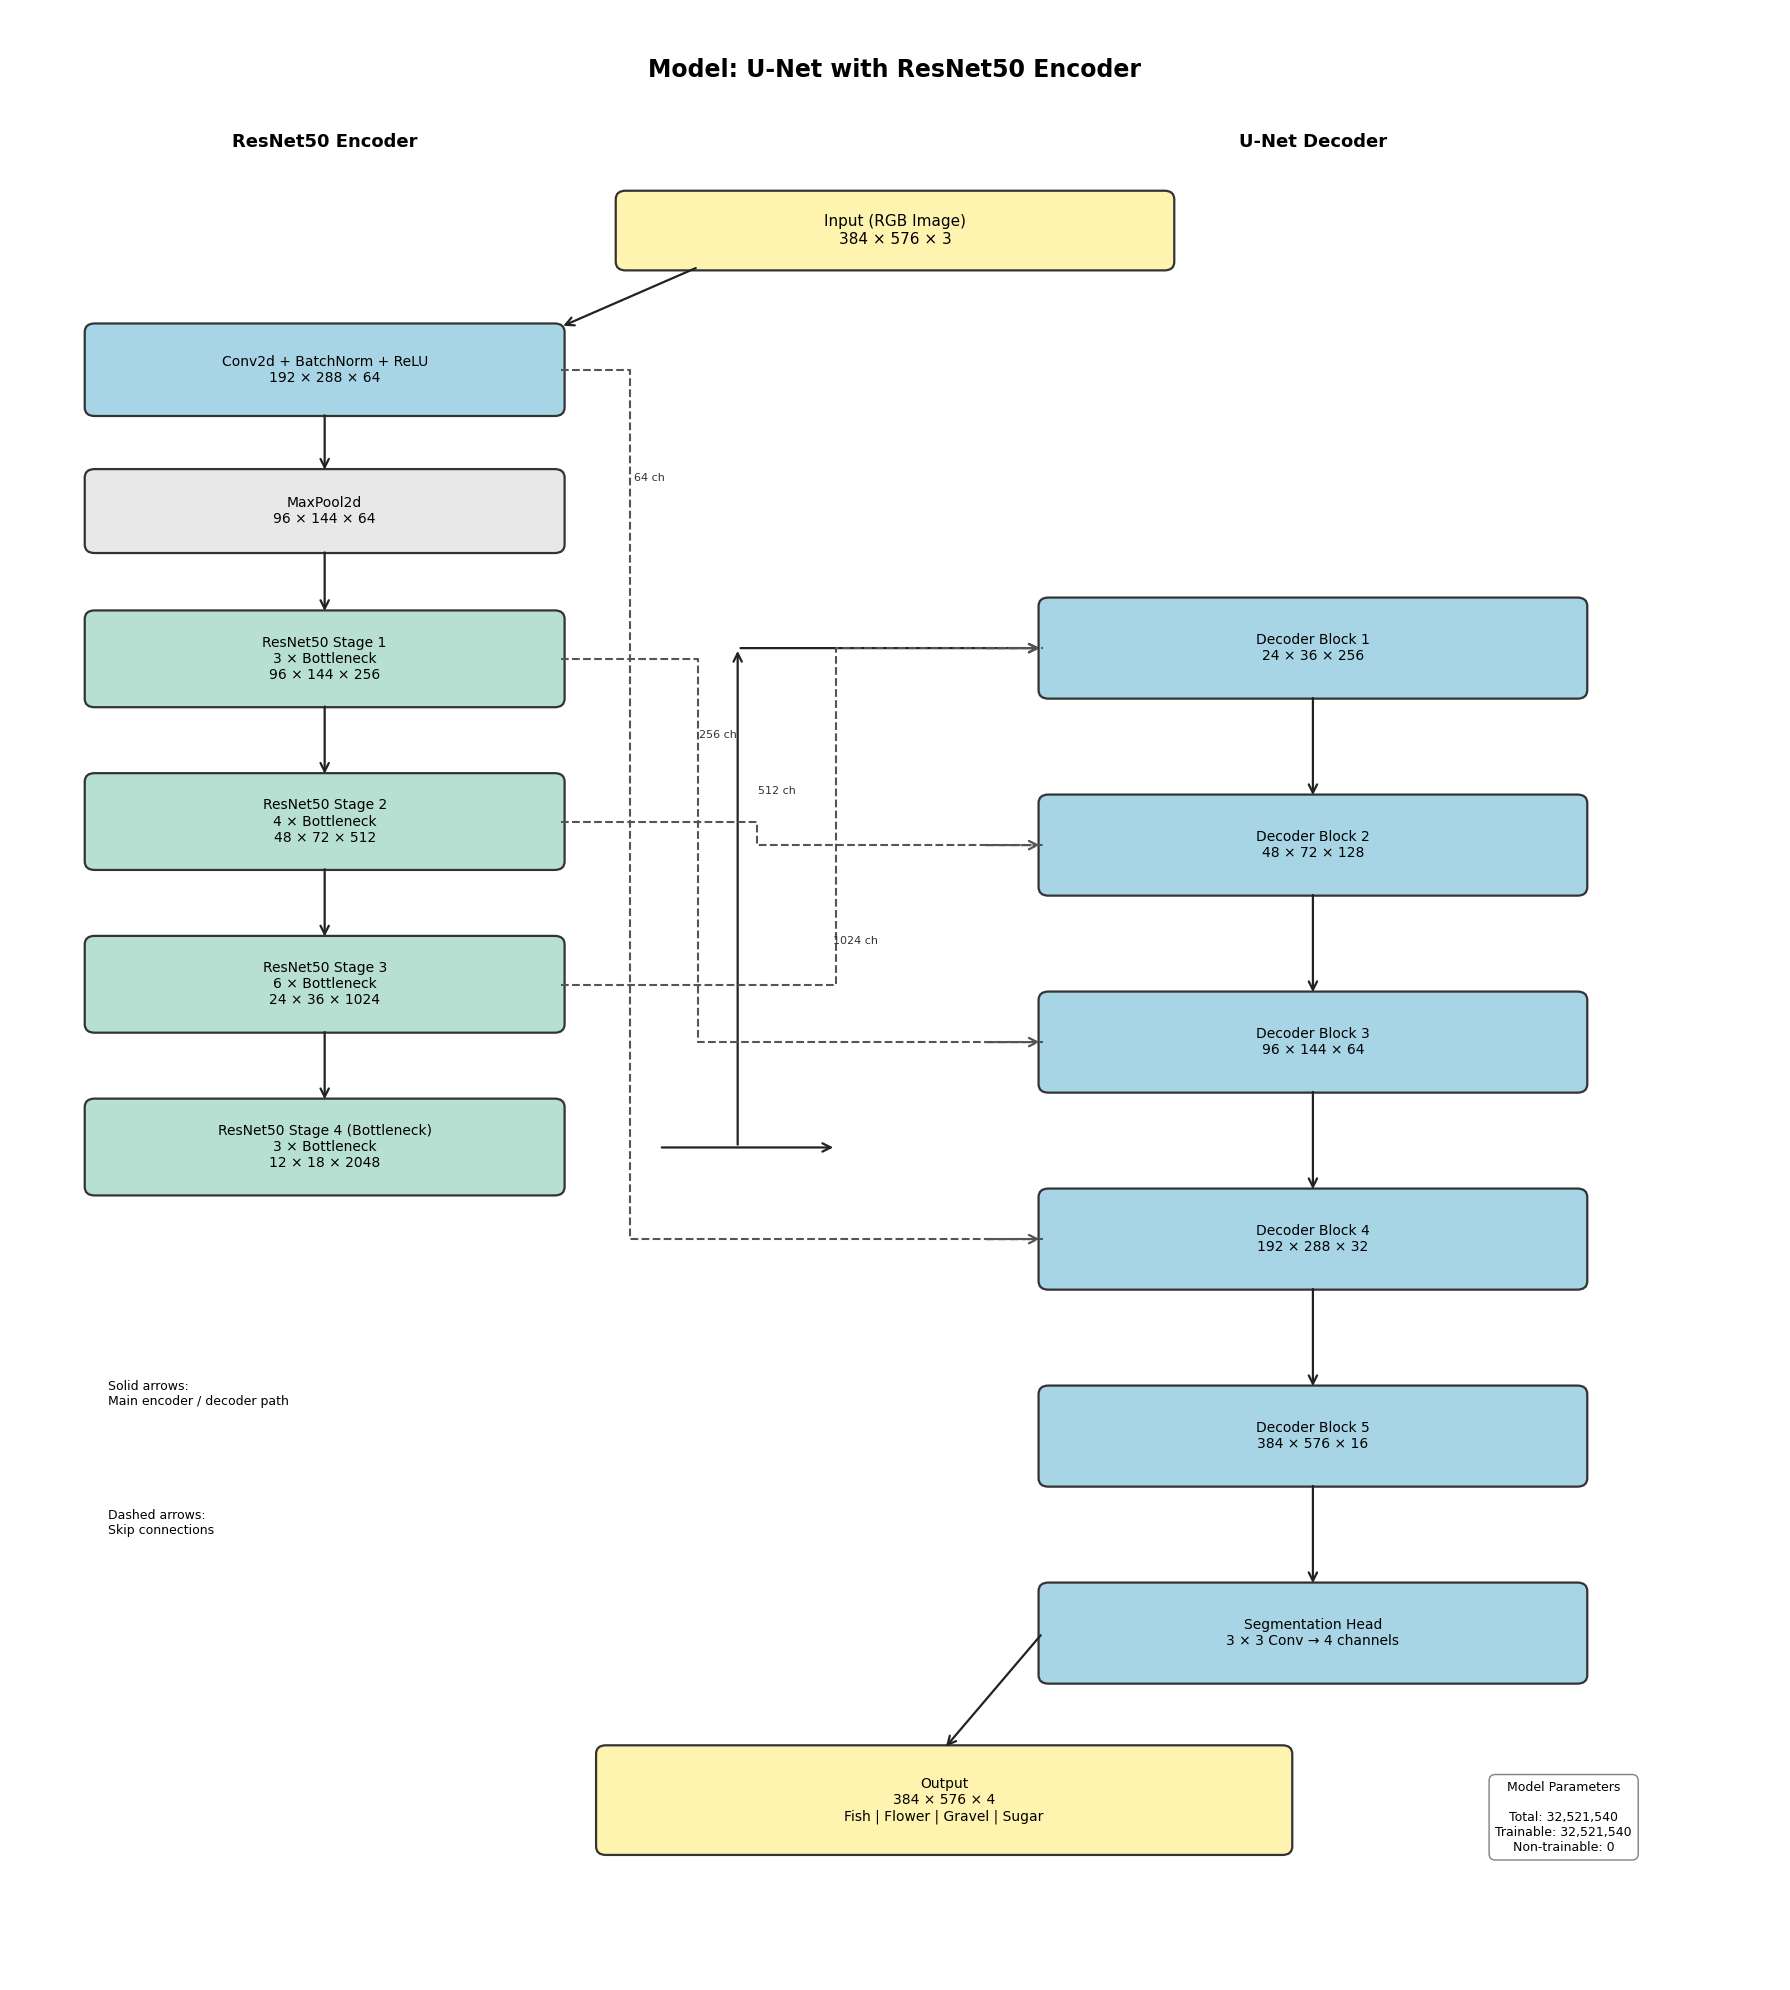

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(18, 20))
ax.set_xlim(0, 18)
ax.set_ylim(0, 23)
ax.axis("off")


# ============================================================
# Helper functions
# ============================================================
def add_box(
    x, y, w, h, text,
    facecolor="white",
    edgecolor="#333333",
    fontsize=10,
    linewidth=1.6
):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.04,rounding_size=0.1",
        facecolor=facecolor,
        edgecolor=edgecolor,
        linewidth=linewidth
    )
    ax.add_patch(box)

    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize
    )


def add_arrow(
    x1, y1, x2, y2,
    linestyle="-",
    linewidth=1.6,
    color="#222222"
):
    ax.add_patch(
        FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="->",
            mutation_scale=15,
            linewidth=linewidth,
            linestyle=linestyle,
            color=color,
            connectionstyle="arc3"
        )
    )


# ============================================================
# Title
# ============================================================
ax.text(
    9, 22.3,
    "Model: U-Net with ResNet50 Encoder",
    ha="center",
    va="center",
    fontsize=17,
    fontweight="bold"
)


# ============================================================
# Section titles
# ============================================================
ax.text(
    3.2, 21.4,
    "ResNet50 Encoder",
    ha="center",
    fontsize=13,
    fontweight="bold"
)

ax.text(
    13.25, 21.4,
    "U-Net Decoder",
    ha="center",
    fontsize=13,
    fontweight="bold"
)


# ============================================================
# INPUT
# ============================================================
add_box(
    6.2, 20.0, 5.6, 0.85,
    "Input (RGB Image)\n384 × 576 × 3",
    facecolor="#FFF3B0",
    fontsize=11
)


# ============================================================
# ENCODER
# ============================================================
add_box(
    0.8, 18.3, 4.8, 1.0,
    "Conv2d + BatchNorm + ReLU\n192 × 288 × 64",
    facecolor="#A8D5E5"
)

add_box(
    0.8, 16.7, 4.8, 0.9,
    "MaxPool2d\n96 × 144 × 64",
    facecolor="#E8E8E8"
)

add_box(
    0.8, 14.9, 4.8, 1.05,
    "ResNet50 Stage 1\n3 × Bottleneck\n96 × 144 × 256",
    facecolor="#B8E0D2"
)

add_box(
    0.8, 13.0, 4.8, 1.05,
    "ResNet50 Stage 2\n4 × Bottleneck\n48 × 72 × 512",
    facecolor="#B8E0D2"
)

add_box(
    0.8, 11.1, 4.8, 1.05,
    "ResNet50 Stage 3\n6 × Bottleneck\n24 × 36 × 1024",
    facecolor="#B8E0D2"
)

add_box(
    0.8, 9.2, 4.8, 1.05,
    "ResNet50 Stage 4 (Bottleneck)\n3 × Bottleneck\n12 × 18 × 2048",
    facecolor="#B8E0D2"
)


# ============================================================
# ENCODER MAIN PATH
# ============================================================

# Input → Conv2d + BatchNorm + ReLU
# Starts from the lower-left edge of the Input box
# and ends at the upper-right edge of the encoder box.
add_arrow(
    7.0, 20.0,
    5.6, 19.3
)

add_arrow(
    3.2, 18.3,
    3.2, 17.6
)

add_arrow(
    3.2, 16.7,
    3.2, 15.95
)

add_arrow(
    3.2, 14.9,
    3.2, 14.05
)

add_arrow(
    3.2, 13.0,
    3.2, 12.15
)

add_arrow(
    3.2, 11.1,
    3.2, 10.25
)


# ============================================================
# DECODER
# ============================================================
add_box(
    10.5, 15.0, 5.5, 1.1,
    "Decoder Block 1\n24 × 36 × 256",
    facecolor="#A8D5E5"
)

add_box(
    10.5, 12.7, 5.5, 1.1,
    "Decoder Block 2\n48 × 72 × 128",
    facecolor="#A8D5E5"
)

add_box(
    10.5, 10.4, 5.5, 1.1,
    "Decoder Block 3\n96 × 144 × 64",
    facecolor="#A8D5E5"
)

add_box(
    10.5, 8.1, 5.5, 1.1,
    "Decoder Block 4\n192 × 288 × 32",
    facecolor="#A8D5E5"
)

add_box(
    10.5, 5.8, 5.5, 1.1,
    "Decoder Block 5\n384 × 576 × 16",
    facecolor="#A8D5E5"
)


# ============================================================
# DECODER MAIN PATH
# ============================================================
add_arrow(
    6.6, 9.72,
    8.4, 9.72
)

add_arrow(
    7.4, 9.72,
    7.4, 15.55
)

add_arrow(
    7.4, 15.55,
    10.5, 15.55
)

add_arrow(
    13.25, 15.0,
    13.25, 13.8
)

add_arrow(
    13.25, 12.7,
    13.25, 11.5
)

add_arrow(
    13.25, 10.4,
    13.25, 9.2
)

add_arrow(
    13.25, 8.1,
    13.25, 6.9
)


# ============================================================
# SKIP CONNECTIONS
# ============================================================
skip_color = "#555555"


# 64 channels:
# Conv2d + BatchNorm + ReLU → Decoder Block 4
ax.plot(
    [5.6, 6.3, 6.3, 10.5],
    [18.8, 18.8, 8.65, 8.65],
    linestyle="--",
    color=skip_color,
    linewidth=1.5
)

add_arrow(
    9.9, 8.65,
    10.5, 8.65,
    linestyle="--",
    color=skip_color
)

ax.text(
    6.5, 17.5,
    "64 ch",
    fontsize=8,
    ha="center",
    color="#333333"
)


# 256 channels:
# ResNet50 Stage 1 → Decoder Block 3
ax.plot(
    [5.6, 7.0, 7.0, 10.5],
    [15.42, 15.42, 10.95, 10.95],
    linestyle="--",
    color=skip_color,
    linewidth=1.5
)

add_arrow(
    9.9, 10.95,
    10.5, 10.95,
    linestyle="--",
    color=skip_color
)

ax.text(
    7.2, 14.5,
    "256 ch",
    fontsize=8,
    ha="center",
    color="#333333"
)


# 512 channels:
# ResNet50 Stage 2 → Decoder Block 2
ax.plot(
    [5.6, 7.6, 7.6, 10.5],
    [13.52, 13.52, 13.25, 13.25],
    linestyle="--",
    color=skip_color,
    linewidth=1.5
)

add_arrow(
    9.9, 13.25,
    10.5, 13.25,
    linestyle="--",
    color=skip_color
)

ax.text(
    7.8, 13.85,
    "512 ch",
    fontsize=8,
    ha="center",
    color="#333333"
)


# 1024 channels:
# ResNet50 Stage 3 → Decoder Block 1
ax.plot(
    [5.6, 8.4, 8.4, 10.5],
    [11.62, 11.62, 15.55, 15.55],
    linestyle="--",
    color=skip_color,
    linewidth=1.5
)

add_arrow(
    9.9, 15.55,
    10.5, 15.55,
    linestyle="--",
    color=skip_color
)

ax.text(
    8.6, 12.1,
    "1024 ch",
    fontsize=8,
    ha="center",
    color="#333333"
)


# ============================================================
# SEGMENTATION HEAD + OUTPUT
# ============================================================
add_box(
    10.5, 3.5, 5.5, 1.1,
    "Segmentation Head\n3 × 3 Conv → 4 channels",
    facecolor="#A8D5E5",
    fontsize=10
)

add_arrow(
    13.25, 5.8,
    13.25, 4.6
)

add_box(
    6.0, 1.5, 7.0, 1.2,
    "Output\n384 × 576 × 4\nFish | Flower | Gravel | Sugar",
    facecolor="#FFF3B0",
    fontsize=10
)

add_arrow(
    10.5, 4.05,
    9.5, 2.7
)


# ============================================================
# MODEL INFO
# ============================================================
ax.text(
    15.8, 1.9,
    "Model Parameters\n\n"
    "Total: 32,521,540\n"
    "Trainable: 32,521,540\n"
    "Non-trainable: 0",
    ha="center",
    va="center",
    fontsize=9,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="gray"
    )
)


# ============================================================
# LEGEND
# ============================================================
ax.text(
    1.0, 7.0,
    "Solid arrows:\nMain encoder / decoder path",
    fontsize=9,
    va="top"
)

ax.text(
    1.0, 5.5,
    "Dashed arrows:\nSkip connections",
    fontsize=9,
    va="top"
)


# ============================================================
# SAVE + SHOW
# ============================================================
plt.tight_layout()

plt.savefig(
    "Figure_UNet_ResNet50_Architecture.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# =========================
# Start Training
# =========================
history = train_model(
    model=model,
    train_loader=train_loader,
    valid_loader=valid_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=criterion,
    device=device,
    epochs=25,
    early_stopping_patience=5
)


Epoch 1/25
----------------------------------------
Train Loss : 0.6636
Train Dice : 0.3145
Val Loss   : 0.6134
Val Dice   : 0.4147
→ Best model saved (Dice: 0.4147)

Epoch 2/25
----------------------------------------
Train Loss : 0.6188
Train Dice : 0.3914
Val Loss   : 0.6028
Val Dice   : 0.4198
→ Best model saved (Dice: 0.4198)

Epoch 3/25
----------------------------------------
Train Loss : 0.6101
Train Dice : 0.4114
Val Loss   : 0.5940
Val Dice   : 0.4349
→ Best model saved (Dice: 0.4349)

Epoch 4/25
----------------------------------------
Train Loss : 0.6056
Train Dice : 0.4146
Val Loss   : 0.5917
Val Dice   : 0.4497
→ Best model saved (Dice: 0.4497)

Epoch 5/25
----------------------------------------
Train Loss : 0.6033
Train Dice : 0.4192
Val Loss   : 0.5932
Val Dice   : 0.4665
→ Best model saved (Dice: 0.4665)

Epoch 6/25
----------------------------------------
Train Loss : 0.6011
Train Dice : 0.4284
Val Loss   : 0.5931
Val Dice   : 0.4707
→ Best model saved (Dice: 0.4707

# Best Model Selection and Loading

In [ ]:
print(os.path.exists(
    "/content/drive/MyDrive/data/checkpoints_resnet50/best_model_resnet50.pth"
))

In [ ]:
# =========================
# Load Best ResNet50 Model
# =========================

model = smp.Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=4,
    activation=None
)

model = model.to(device)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/data/checkpoints_resnet50/best_model_resnet50.pth",
        map_location=device
    )
)

model.eval()

print("Best ResNet50 model loaded successfully.")

# 🔵 **Model Evaluation**

In [ ]:
# import os

# base_path = "/content/drive/MyDrive"

# for root, dirs, files in os.walk(base_path):
#     for file in files:
#         if any(word in file.lower() for word in ["history", "loss", "training", "resnet50"]):
#             print(os.path.join(root, file))

In [ ]:
# import json

# notebook_path = "/content/drive/MyDrive/Colab Notebooks/ResNet50CloudSegmentationProject.ipynb"

# with open(notebook_path, "r", encoding="utf-8") as f:
#     notebook = json.load(f)

# for i, cell in enumerate(notebook["cells"]):
#     source = "".join(cell.get("source", []))

#     if "history" in source or "train_loss" in source or "val_loss" in source:
#         print(f"\n===== CELL {i} =====")
#         print(source[:3000])

In [ ]:
# import json

# notebook_path = "/content/drive/MyDrive/Colab Notebooks/ResNet50CloudSegmentationProject.ipynb"

# with open(notebook_path, "r", encoding="utf-8") as f:
#     notebook = json.load(f)

# cell = notebook["cells"][31]

# print("Cell type:", cell["cell_type"])
# print("\n--- OUTPUT ---")

# for output in cell.get("outputs", []):
#     if "text" in output:
#         print("".join(output["text"]))

In [ ]:
# epochs = range(1, len(history["train_loss"]) + 1)

# plt.figure(figsize=(12, 5))

# plt.plot(
#     epochs,
#     history["train_loss"],
#     label="Train Loss"
# )

# plt.plot(
#     epochs,
#     history["val_loss"],
#     label="Validation Loss"
# )

# plt.title("Training and Validation Loss")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.legend()
# plt.grid()

# plt.tight_layout()
# plt.show()

# Training Loss + Validation Loss

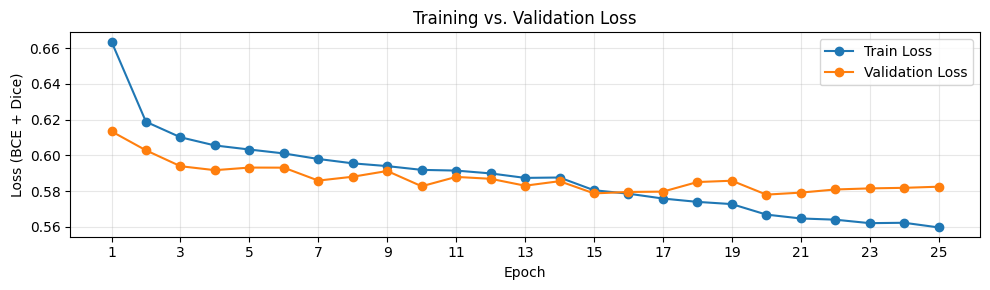

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

# Show every second epoch label
epoch_ticks = list(epochs)[::2]

plt.figure(figsize=(10, 3))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("Training vs. Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (BCE + Dice)")
plt.xticks(epoch_ticks)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Training Dice + Validation Dice

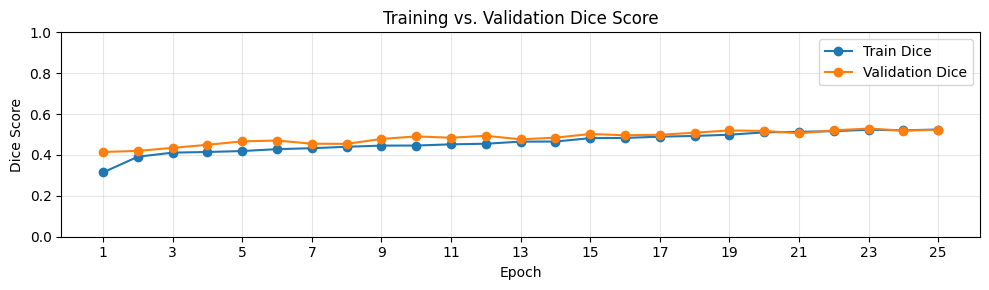

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_dice"]) + 1)

# Show every second epoch label
epoch_ticks = list(epochs)[::2]

plt.figure(figsize=(10, 3))

plt.plot(
    epochs,
    history["train_dice"],
    marker="o",
    label="Train Dice"
)

plt.plot(
    epochs,
    history["val_dice"],
    marker="o",
    label="Validation Dice"
)

plt.title("Training vs. Validation Dice Score")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.xticks(epoch_ticks)
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Final Validation Performance

In [ ]:
model.eval()

val_loss, val_dice = validate(
    model,
    valid_loader,
    criterion,
    device
)

print("\nValidation performance")
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Dice: {val_dice:.4f}")

# Validation Dice Score Evaluation

In [ ]:
@torch.no_grad()
def evaluate_model(model, loader, device, threshold=0.5):
    model.eval()

    total_dice = 0.0
    num_batches = 0

    for images, masks, _ in loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        dice = dice_score(logits, masks, threshold=threshold)

        total_dice += dice
        num_batches += 1

    return total_dice / num_batches


val_dice = evaluate_model(
    model,
    valid_loader,
    device,
    threshold=0.5
)

print(f"Validation Dice Score: {val_dice:.4f}")

# Per-Class Dice Score Evaluation

In [ ]:
@torch.no_grad()
def per_class_dice(model, loader, device, threshold=0.5):
    model.eval()

    intersection = torch.zeros(4, device=device)
    cardinality = torch.zeros(4, device=device)

    for images, masks, _ in loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float()

        intersection += (preds * masks).sum(dim=(0, 2, 3))
        cardinality += (
            preds.sum(dim=(0, 2, 3))
            + masks.sum(dim=(0, 2, 3))
        )

    dice = (
        2 * intersection + 1e-5
    ) / (
        cardinality + 1e-5
    )

    return dice.cpu().numpy()


class_names = [
    "Fish",
    "Flower",
    "Gravel",
    "Sugar"
]

class_dice = per_class_dice(
    model,
    valid_loader,
    device,
    threshold=0.5
)

for name, score in zip(class_names, class_dice):
    print(f"{name}: {score:.4f}")

overall_dice = np.mean(class_dice)

print(f"Overall Dice Score: {overall_dice:.4f}")

Fish: 0.5478
Flower: 0.6962
Gravel: 0.5729
Sugar: 0.6301
Overall Dice Score: 0.6118


# IoU Evaluation

In [ ]:
# =========================
# IoU Evaluation
# =========================

@torch.no_grad()
def per_class_iou(model, loader, device, threshold=0.5):
    model.eval()

    intersection = torch.zeros(4, device=device)
    union = torch.zeros(4, device=device)

    for images, masks, _ in loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)

        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float()

        intersection += (
            preds * masks
        ).sum(dim=(0, 2, 3))

        union += (
            preds + masks - preds * masks
        ).sum(dim=(0, 2, 3))

    iou = (
        intersection + 1e-5
    ) / (
        union + 1e-5
    )

    return iou.cpu().numpy()


class_iou = per_class_iou(
    model,
    valid_loader,
    device,
    threshold=0.5
)

for name, score in zip(class_names, class_iou):
    print(f"{name}: {score:.4f}")

print(f"Mean IoU: {class_iou.mean():.4f}")

Fish: 0.3773
Flower: 0.5340
Gravel: 0.4014
Sugar: 0.4600
Mean IoU: 0.4432


# Validation Performance — Dice & IoU

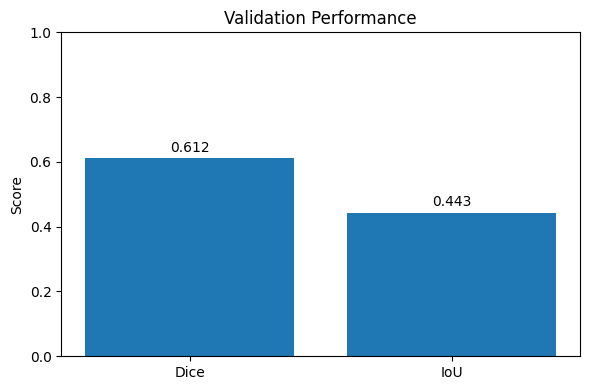

In [ ]:
metrics_to_plot = {
    "Dice": overall_dice,
    "IoU": class_iou.mean()
}

plt.figure(figsize=(6, 4))

plt.bar(
    metrics_to_plot.keys(),
    metrics_to_plot.values()
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Validation Performance")

for i, value in enumerate(metrics_to_plot.values()):
    plt.text(
        i,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )
_
plt.tight_layout()
plt.show()

# Prepare Validation Predictions for Visualization

In [ ]:
class_names = ["Fish", "Flower", "Gravel", "Sugar"]

model.eval()

with torch.no_grad():
    images, masks, image_ids = next(iter(valid_loader))

    images = images.to(device)

    logits = model(images)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

print("Images:", images.shape)
print("Ground Truth:", masks.shape)
print("Prediction:", preds.shape)

# Prediction Visualization

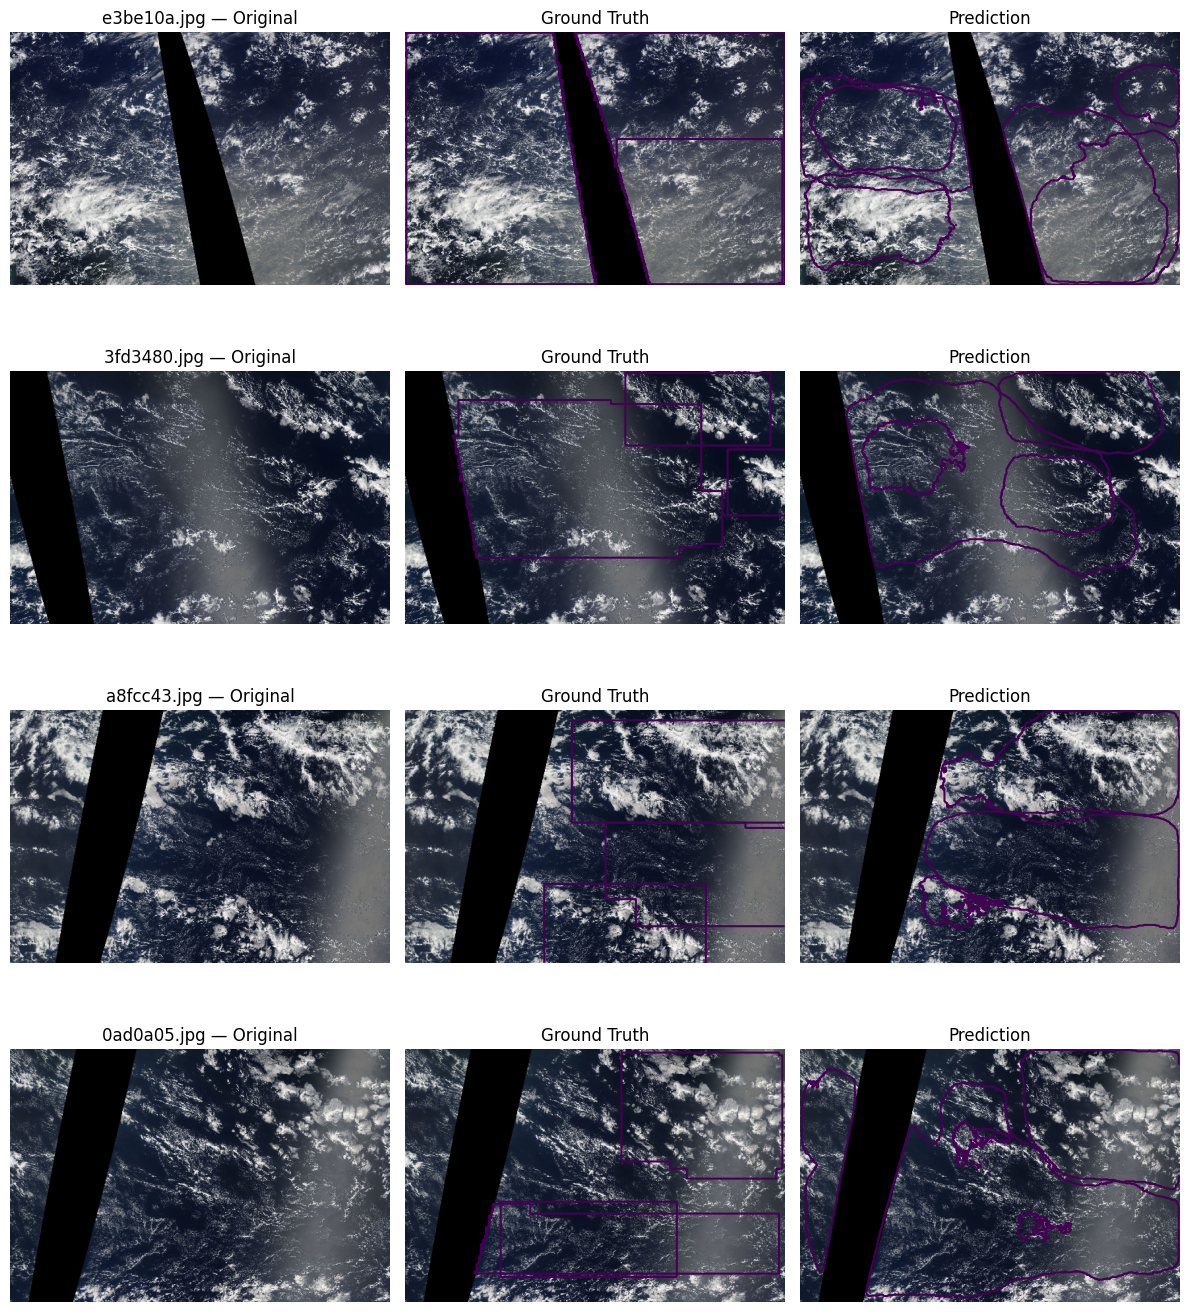

In [ ]:
class_names = ["Fish", "Flower", "Gravel", "Sugar"]

fig, axes = plt.subplots(
    4, 3,
    figsize=(12, 14)
)

for i in range(4):

    # Original image
    image = images[i].cpu().numpy()
    image = image.transpose(1, 2, 0)

    # Undo ImageNet normalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = image * std + mean
    image = np.clip(image, 0, 1)

    # Ground truth
    ground_truth = masks[i].cpu().numpy()

    # Prediction
    prediction = preds[i].cpu().numpy()

    # Original image
    axes[i, 0].imshow(image)
    axes[i, 0].set_title(f"{image_ids[i]} — Original")
    axes[i, 0].axis("off")

    # Ground Truth
    axes[i, 1].imshow(image)

    for c in range(4):
        if ground_truth[c].sum() > 0:
            axes[i, 1].contour(
                ground_truth[c],
                levels=[0.5],
                linewidths=1.5
            )

    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

    # Prediction
    axes[i, 2].imshow(image)

    for c in range(4):
        if prediction[c].sum() > 0:
            axes[i, 2].contour(
                prediction[c],
                levels=[0.5],
                linewidths=1.5
            )

    axes[i, 2].set_title("Prediction")
    axes[i, 2].axis("off")


plt.tight_layout()
plt.show()

# 🔵 **Test Prediction & Final Submission**

# Test Set Prediction

In [ ]:
TEST_DIR = TEST_IMAGES_DIR

CLASSES = [
    "Fish",
    "Flower",
    "Gravel",
    "Sugar"
]

THRESHOLDS = np.array([
    0.5,
    0.5,
    0.5,
    0.5
])

# Get test image names
test_images = [
    f for f in os.listdir(TEST_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Randomly choose 4 images
random_images = np.random.choice(
    test_images,
    size=4,
    replace=False
)

print("Selected images:")
print(random_images)

# Load images
X_test = []

for image_name in random_images:

    image_path = os.path.join(
        TEST_DIR,
        image_name
    )

    image = cv2.imread(image_path)

    if image is None:
        raise FileNotFoundError(
            f"Could not load: {image_path}"
        )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    image = cv2.resize(
        image,
        (576, 384)
    )

    image = image.astype(np.float32) / 255.0

    # ImageNet normalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = (image - mean) / std

    # HWC → CHW
    image = image.transpose(2, 0, 1)

    X_test.append(image)

X_test = np.array(
    X_test,
    dtype=np.float32
)

print("Input shape:", X_test.shape)

# Convert to PyTorch tensor
X_test = torch.tensor(X_test).to(device)

# Prediction
model.eval()

with torch.no_grad():
    logits = model(X_test)
    pred_prob = torch.sigmoid(logits)

# Convert probabilities to masks
thresholds = torch.tensor(
    THRESHOLDS,
    dtype=torch.float32,
    device=device
).view(1, 4, 1, 1)

pred_mask = (
    pred_prob > thresholds
).float()

print("Prediction shape:", pred_mask.shape)

Selected images:
['016eec3.jpg' 'e5705c2.jpg' '78edb3a.jpg' '8c5937e.jpg']
Input shape: (4, 3, 384, 576)
Prediction shape: torch.Size([4, 4, 384, 576])


# Test Prediction Visualization

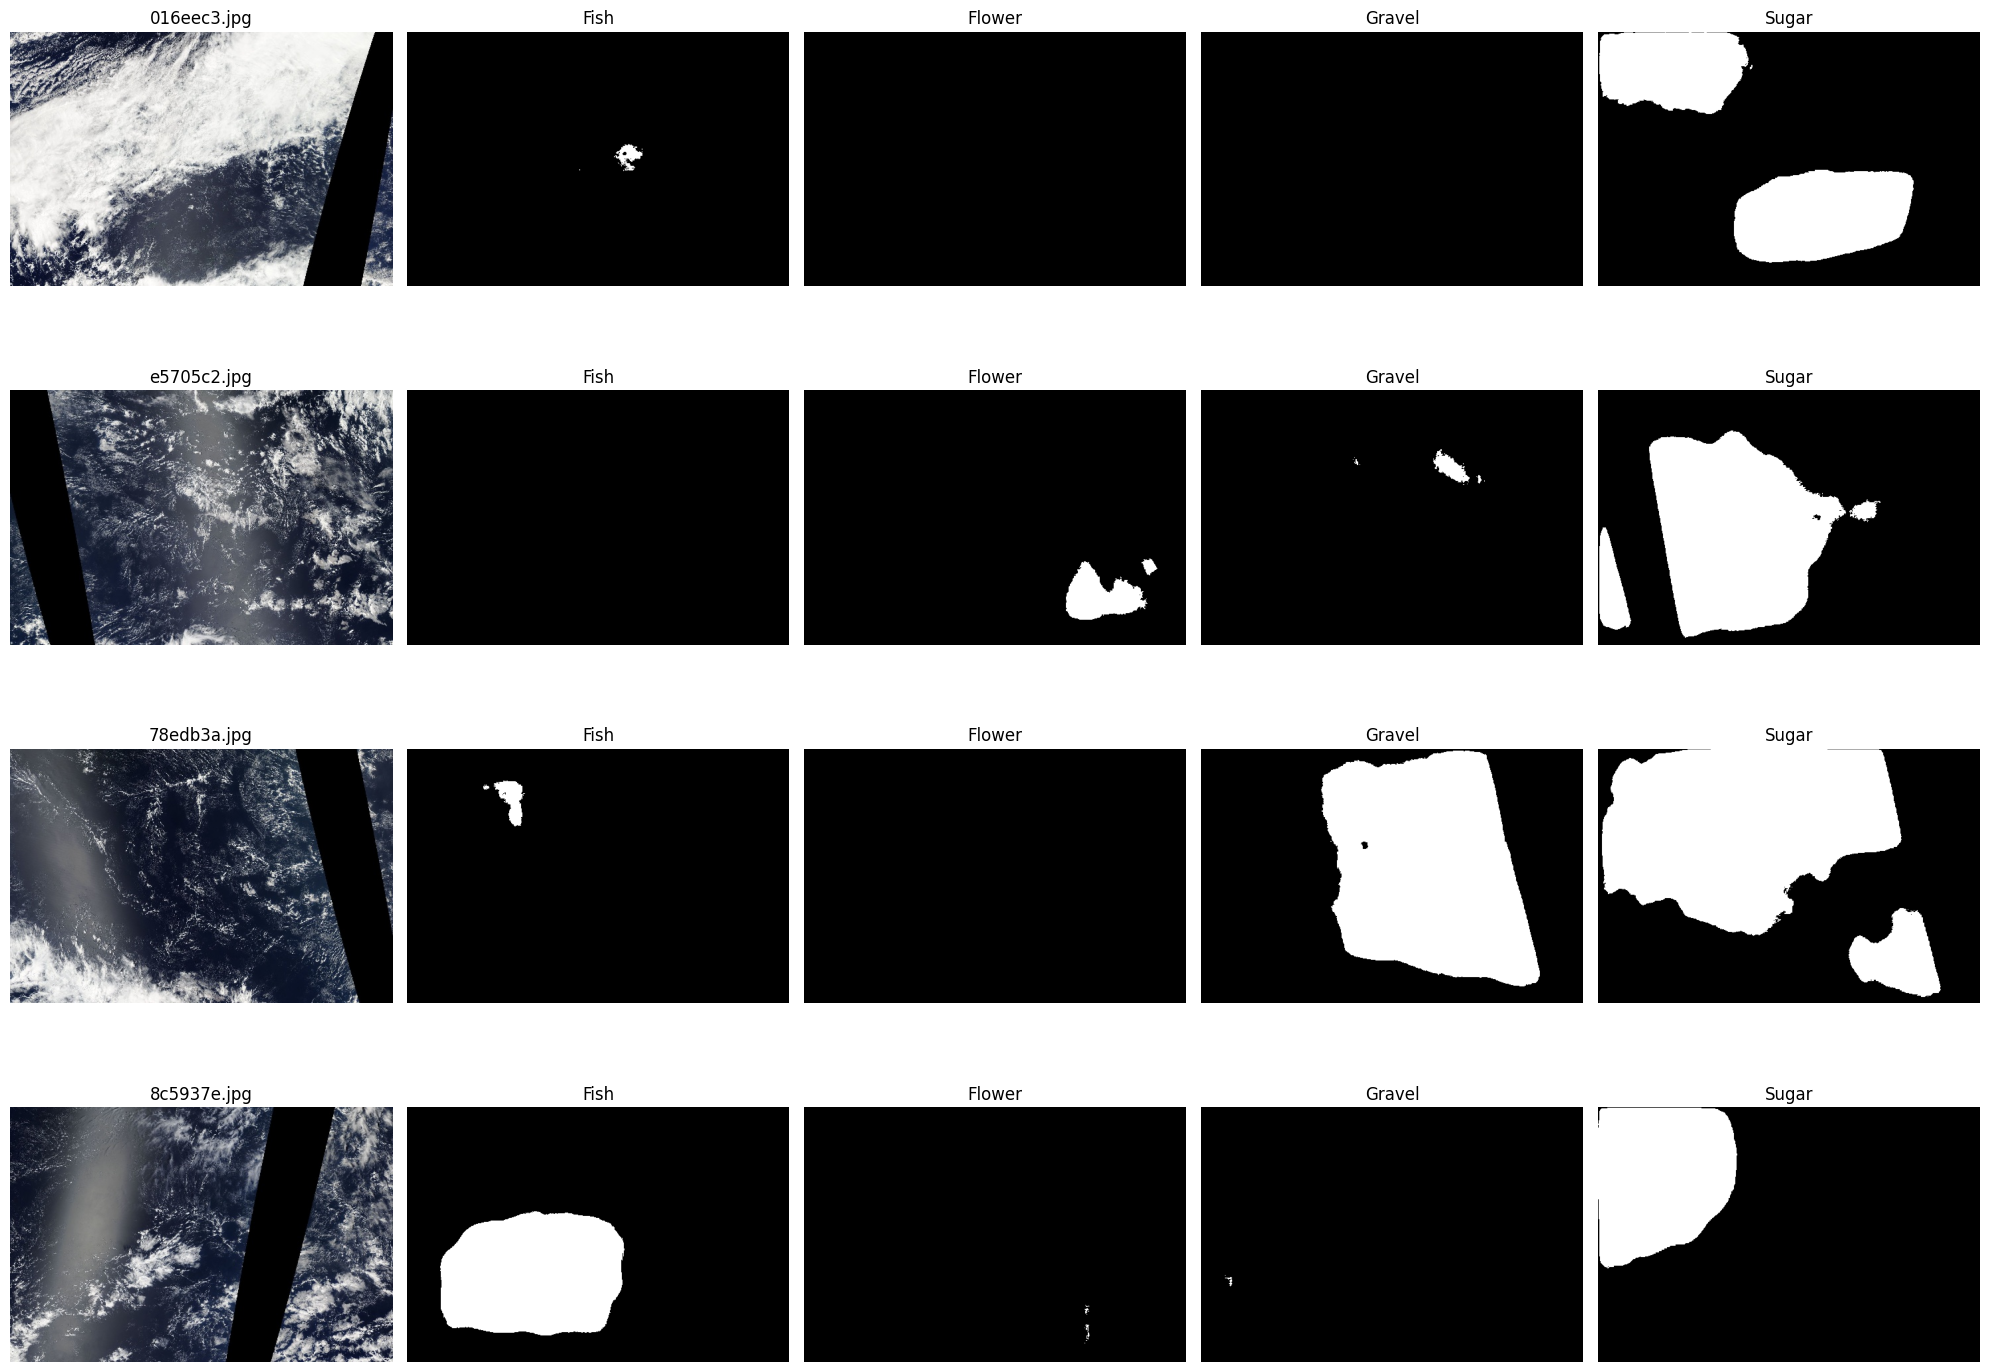

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(
    4,
    5,
    figsize=(20, 15)
)

for row in range(4):

    # Original satellite image
    image = X_test[row].cpu().numpy().transpose(1, 2, 0)

    # Undo ImageNet normalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = image * std + mean
    image = np.clip(image, 0, 1)

    ax[row, 0].imshow(image)
    ax[row, 0].set_title(random_images[row])
    ax[row, 0].axis("off")

    # Fish / Flower / Gravel / Sugar
    for class_index, class_name in enumerate(CLASSES):

        mask = pred_mask[
            row,
            class_index
        ].cpu().numpy()

        ax[row, class_index + 1].imshow(
            mask,
            cmap="gray"
        )

        ax[row, class_index + 1].set_title(
            class_name
        )

        ax[row, class_index + 1].axis("off")

plt.tight_layout()
plt.show()

# RLE Encoding and Test Image Preparation

In [ ]:
HEIGHT = 384
WIDTH = 576

CLASSES = [
    "Fish",
    "Flower",
    "Gravel",
    "Sugar"
]

TEST_DIR = TEST_IMAGES_DIR

THRESHOLDS = np.array([
    0.5,   # Fish
    0.5,   # Flower
    0.5,   # Gravel
    0.5    # Sugar
])

BATCH_SIZE = 4


def rle_encode(mask):

    # Flatten in the same direction used by the decoder
    pixels = mask.flatten(order="F")

    # Add zeros at beginning and end
    pixels = np.concatenate(
        [[0], pixels, [0]]
    )

    # Find changes between 0 and 1
    runs = np.where(
        pixels[1:] != pixels[:-1]
    )[0] + 1

    # Convert start/end positions to start/length
    runs[1::2] -= runs[::2]

    return " ".join(
        str(x) for x in runs
    )


test_images = sorted([
    file
    for file in os.listdir(TEST_DIR)
    if file.lower().endswith(
        (".jpg", ".jpeg", ".png")
    )
])

print("Number of test images:", len(test_images))
print(test_images[:5])

Number of test images: 3698
['002f507.jpg', '0035ae9.jpg', '0038327.jpg', '004f759.jpg', '005ba08.jpg']


# Prediction on ALL Test Images

In [ ]:
all_predictions = []

model.eval()

for start in range(0, len(test_images), BATCH_SIZE):

    batch_images = test_images[start:start + BATCH_SIZE]

    X_batch = []

    for image_name in batch_images:

        image_path = os.path.join(TEST_DIR, image_name)

        image = cv2.imread(image_path)

        if image is None:
            raise FileNotFoundError(
                f"Could not load: {image_path}"
            )

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        image = cv2.resize(
            image,
            (WIDTH, HEIGHT)
        )

        image = image.astype(np.float32) / 255.0

        mean = np.array(
            [0.485, 0.456, 0.406]
        )

        std = np.array(
            [0.229, 0.224, 0.225]
        )

        image = (image - mean) / std

        image = image.transpose(2, 0, 1)

        X_batch.append(image)

    X_batch = torch.tensor(
        np.array(X_batch),
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():

        logits = model(X_batch)

        probabilities = torch.sigmoid(logits)

        thresholds = torch.tensor(
            THRESHOLDS,
            dtype=torch.float32,
            device=device
        ).view(1, 4, 1, 1)

        predictions = (
            probabilities > thresholds
        ).float()

    all_predictions.append(
        predictions.cpu().numpy()
    )

all_predictions = np.concatenate(
    all_predictions,
    axis=0
)

print("Shape:", all_predictions.shape)
print("Dtype:", all_predictions.dtype)
print("Min:", all_predictions.min())
print("Max:", all_predictions.max())

Shape: (3698, 4, 384, 576)
Dtype: float32
Min: 0.0
Max: 1.0


# Create Final Output

In [ ]:
submission_rows = []

for image_index, image_name in enumerate(test_images):

    for class_index, class_name in enumerate(CLASSES):

        mask = all_predictions[
            image_index,
            class_index
        ]

        encoded_pixels = rle_encode(mask)

        submission_rows.append({
            "Image_Label": f"{image_name}_{class_name}",
            "EncodedPixels": encoded_pixels
        })

submission_df = pd.DataFrame(
    submission_rows
)

print("Output shape:", submission_df.shape)

print("\nFirst rows:")
print(submission_df.head())

Output shape: (14792, 2)

First rows:
          Image_Label                                      EncodedPixels
0    002f507.jpg_Fish                                                   
1  002f507.jpg_Flower                                                   
2  002f507.jpg_Gravel  403 84 489 43 534 15 557 5 586 2 595 25 711 2 ...
3   002f507.jpg_Sugar  144016 1 144396 1 144779 8 144788 1 145163 10 ...
4    0035ae9.jpg_Fish  146826 4 147209 6 147592 9 147976 6 148356 1 1...


# Save Final CSV

In [ ]:
OUTPUT_PATH = "/content/cloud_data/final_Testpredictions_ResNet50.csv"

submission_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Final output saved to:")
print(OUTPUT_PATH)

Final output saved to:
/content/cloud_data/final_Testpredictions_ResNet50.csv


# Validate Final Submission

In [ ]:
OUTPUT_PATH = "/content/cloud_data/final_Testpredictions_ResNet50.csv"

final_df = pd.read_csv(OUTPUT_PATH)

print("Output shape:", final_df.shape)

print("\nColumns:")
print(final_df.columns.tolist())

print("\nFirst 8 rows:")
print(final_df.head(8))

print(
    "Number of unique images:",
    final_df["Image_Label"]
    .str.rsplit("_", n=1)
    .str[0]
    .nunique()
)

print("\nRows per image:")
print(
    final_df["Image_Label"]
    .str.rsplit("_", n=1)
    .str[0]
    .value_counts()
    .value_counts()
)

print("\nRows per class:")
print(
    final_df["Image_Label"]
    .str.rsplit("_", n=1)
    .str[1]
    .value_counts()
)

Output shape: (14792, 2)

Columns:
['Image_Label', 'EncodedPixels']

First 8 rows:
          Image_Label                                      EncodedPixels
0    002f507.jpg_Fish                                                NaN
1  002f507.jpg_Flower                                                NaN
2  002f507.jpg_Gravel  403 84 489 43 534 15 557 5 586 2 595 25 711 2 ...
3   002f507.jpg_Sugar  144016 1 144396 1 144779 8 144788 1 145163 10 ...
4    0035ae9.jpg_Fish  146826 4 147209 6 147592 9 147976 6 148356 1 1...
5  0035ae9.jpg_Flower                                                NaN
6  0035ae9.jpg_Gravel  490 2 494 1 500 3 561 1 572 7 580 4 591 2 598 ...
7   0035ae9.jpg_Sugar  22198 1 22581 5 22588 2 22591 1 22960 16 22978...
Number of unique images: 3698

Rows per image:
count
4    3698
Name: count, dtype: int64

Rows per class:
Image_Label
Fish      3698
Flower    3698
Gravel    3698
Sugar     3698
Name: count, dtype: int64


# Test Prediction Overlay Visualization

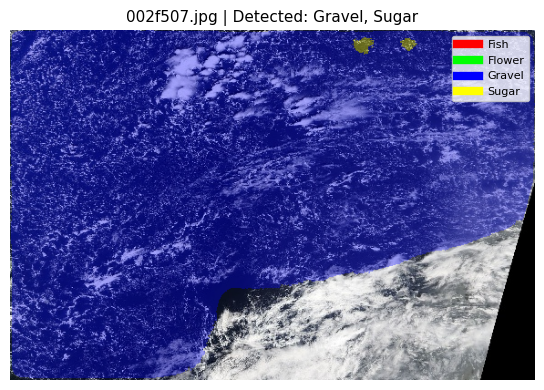

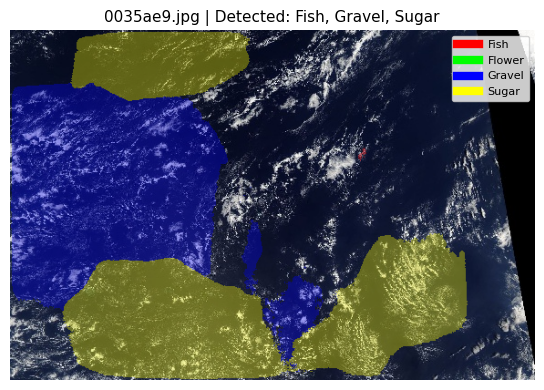

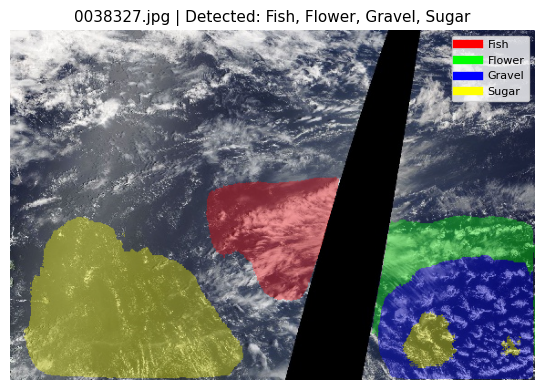

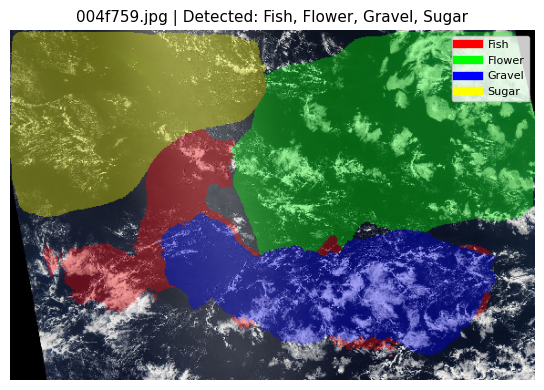

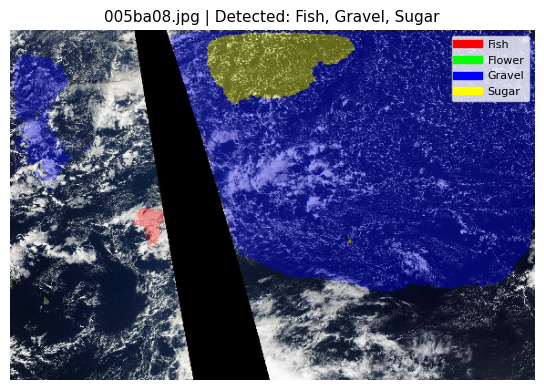

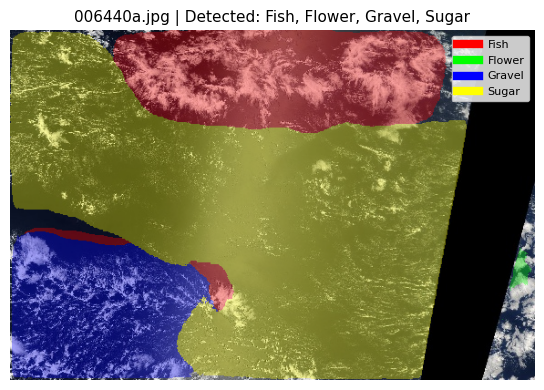

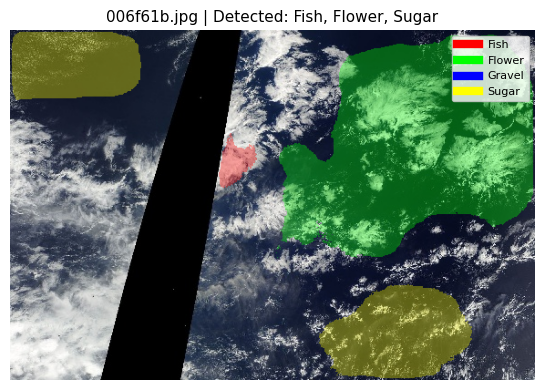

In [ ]:
N_IMAGES = 7

CLASSES = [
    "Fish",
    "Flower",
    "Gravel",
    "Sugar"
]

COLORS = [
    (255, 0, 0),      # Fish
    (0, 255, 0),      # Flower
    (0, 0, 255),      # Gravel
    (255, 255, 0)     # Sugar
]

for image_index in range(N_IMAGES):

    image_name = test_images[image_index]

    image_path = os.path.join(
        TEST_DIR,
        image_name
    )

    image = cv2.imread(image_path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    overlay = image.copy()

    detected_labels = []

    for class_index, class_name in enumerate(CLASSES):

        mask = all_predictions[
            image_index,
            class_index
        ]

        if mask.sum() > 0:

            detected_labels.append(class_name)

            overlay[mask == 1] = COLORS[class_index]

    result = cv2.addWeighted(
        image,
        0.65,
        overlay,
        0.35,
        0
    )

    plt.figure(figsize=(7, 4))

    plt.imshow(result)

    detected_text = (
        ", ".join(detected_labels)
        if detected_labels
        else "None"
    )

    plt.title(
        f"{image_name} | Detected: {detected_text}",
        fontsize=11
    )

    plt.axis("off")

    for class_name, color in zip(CLASSES, COLORS):

        plt.plot(
            [],
            [],
            color=np.array(color) / 255,
            linewidth=6,
            label=class_name
        )

    plt.legend(
        loc="upper right",
        fontsize=8
    )

    plt.tight_layout()
    plt.show()